In [5]:
import pandas as pd
import plotly.express as px

In [6]:
df=pd.read_csv(r"C:\Users\User\Desktop\Hotel_pred\Data\Raw\hotel_bookings_updated_2024.csv")

In [21]:

def plot_target_pie(df):
    fig = px.pie(
        df,
        names='is_canceled',
        title='Canceled vs Not Canceled Bookings'
    )
    fig.show(renderer="browser")


def plot_hotel_cancellation_percentage(df):
    counts = (
        df.groupby(['hotel', 'is_canceled'])
        .size()
        .reset_index(name='count')
    )

    counts['percentage'] = (
        counts['count'] /
        counts.groupby('hotel')['count'].transform('sum') * 100
    )

    fig = px.bar(
        counts,
        x='hotel',
        y='percentage',
        color='is_canceled',
        barmode='stack',
        text=counts['percentage'].round(1),
        title='Hotel Type vs Cancellation Percentage'
    )

    fig.update_layout(yaxis_title='Percentage (%)')
    fig.show(renderer="browser")




def plot_lead_time_hist(df):
    fig = px.histogram(
        df,
        x='lead_time',
        color='is_canceled',
        nbins=50,
        title='Lead Time Distribution by Cancellation'
    )
    fig.show(renderer="browser")




def plot_customer_type_pie(df):
    fig = px.pie(
        df,
        names='customer_type',
        title='Customer Type Distribution'
    )
    fig.show(renderer="browser")



def plot_special_requests(df):
    fig = px.histogram(
        df,
        x='total_of_special_requests',
        color='is_canceled',
        title='Special Requests vs Cancellation'
    )
    fig.show(renderer="browser")


plot_target_pie(df)
plot_hotel_cancellation_percentage(df)
plot_lead_time_hist(df)
plot_customer_type_pie(df)
plot_special_requests(df)



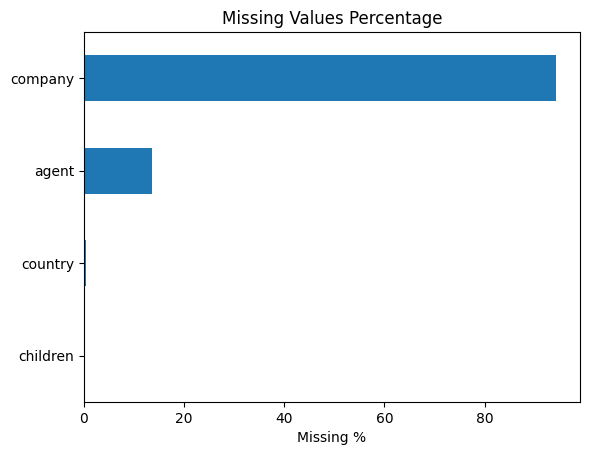

In [8]:
import matplotlib.pyplot as plt

def plot_missing(df):
    missing = df.isnull().mean() * 100
    missing = missing[missing > 0].sort_values()

    missing.plot(kind='barh')
    plt.xlabel("Missing %")
    plt.title("Missing Values Percentage")
    plt.show()

plot_missing(df)